# 06_Pipeline D Controlled Tokenizer Comparison.ipynb
Shared Tokenizer --- TF-IDF vs Fine-Tuned RoBERTa (Architecture-Controlled Study)

## Pipeline D: Controlled Tokenizer Comparison
*Is the Transformer’s “architecture” responsible for gains, or just its tokenizer?*

This notebook performs a controlled, architecture-isolated comparison, where ALL models use the same tokenizer (RoBERTa’s BPE tokenizer).

This removes vocabulary & tokenization differences and allows a clean, scientifically valid analysis of what performance comes from:

The tokenizer vs The actual Transformer architecture

This notebook includes:

- Shared-tokenizer text preprocessing
- Shared-tokenizer TF-IDF
- Linear classifiers (Logistic Regression, Linear SVM)
- Loading the fine-tuned RoBERTa (.pth) model
- Evaluation (Accuracy, F1, ROC-AUC, Confusion Matrices)
- Interpretability (coefficients, top features)
- Final comparison table

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

# Transformers
import torch
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
# Loading Dataset:
file_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_10K.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print(df.shape)
df.head()


Dataset loaded successfully!
(10000, 2)


,Text,Label
0,6 top keywords used in the meta keywords tags ...,0
1,The officer leading the police investigation i...,0
2,It 's biology vs you . Our ancestors were prog...,0
3,Short version : Lazy programmers . Long versio...,0
4,But after the formation of infertility jumbled...,0


In [4]:
# Train-Test Split:

X = df["Text"].astype(str)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 8000 | Test size: 2000


#### Loading the SHARED RoBERTa Tokenizer

**Why this matters**:
- To isolate tokenizer effects, we must force ALL models (TF-IDF and RoBERTa) to use the same exact tokenizer.

This ensures:
- SAME token boundaries
- SAME normalization
- SAME subword segmentation

Only the classifier differs.

In [5]:
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
print("RoBERTa tokenizer loaded.")


RoBERTa tokenizer loaded.


#### Shared-Tokenizer TF-IDF Vectorization

**How this works:**
Instead of word-level TF-IDF, we run TF-IDF on tokenized text using RoBERTa BPE tokens.

This gives:
- identical text representation rules across models
- subword-level TF-IDF
- removal of architectural advantage

In [6]:
def roberta_tokenize(text):
    """Return a whitespace-joined string of BPE tokens so TF-IDF can use them."""
    tokens = tokenizer.tokenize(text)
    return " ".join(tokens)

X_train_tok = X_train.apply(roberta_tokenize)
X_test_tok = X_test.apply(roberta_tokenize)

print("Tokenization complete.")


Token indices sequence length is longer than the specified maximum sequence length for this model (675 > 512). Running this sequence through the model will result in indexing errors


Tokenization complete.


#### TF-IDF using BPE tokens

In [7]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train_tok)
X_test_tfidf = tfidf.transform(X_test_tok)

print("TF-IDF matrix shapes:", X_train_tfidf.shape, X_test_tfidf.shape)


TF-IDF matrix shapes: (8000, 20000) (2000, 20000)


#### Linear Models on Shared-Tokenizer TF-IDF

Models:

Logistic Regression

LinearSVC (best for sparse high-dimensional BPE features)

In [ ]:
# Helper for model evaluation

def evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # probabilistic output if available
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # approximating using decision_function
        y_proba = model.decision_function(X_test)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    print(f"\n{name} Results")
    print(classification_report(y_test, y_pred, digits=3))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"{name} — ROC Curve")
    plt.show()

    return metrics


#### Training Models


Logistic Regression (Shared-Tokenizer TF-IDF) Results
              precision    recall  f1-score   support

           0      0.818     0.792     0.805      1000
           1      0.798     0.824     0.811      1000

    accuracy                          0.808      2000
   macro avg      0.808     0.808     0.808      2000
weighted avg      0.808     0.808     0.808      2000



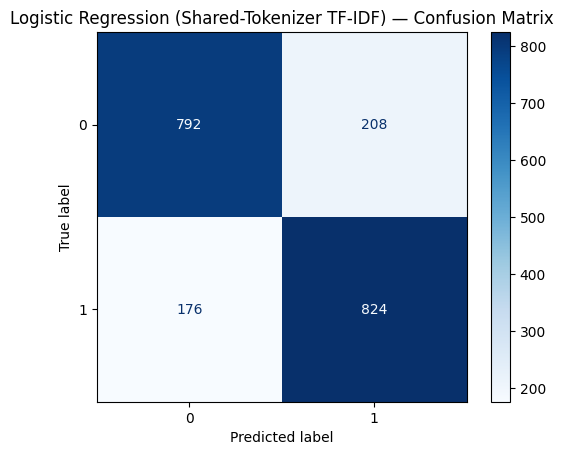

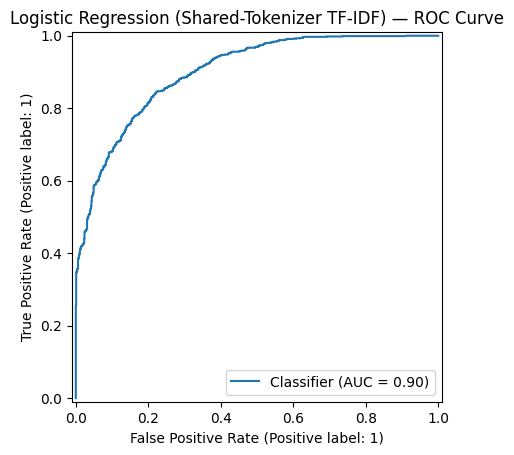


Linear SVM (Shared-Tokenizer TF-IDF) Results
              precision    recall  f1-score   support

           0      0.805     0.803     0.804      1000
           1      0.803     0.805     0.804      1000

    accuracy                          0.804      2000
   macro avg      0.804     0.804     0.804      2000
weighted avg      0.804     0.804     0.804      2000



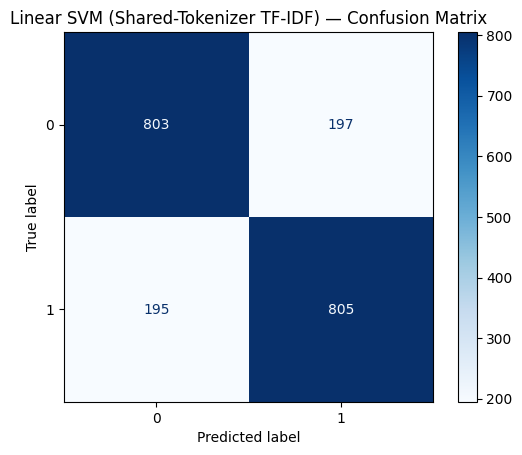

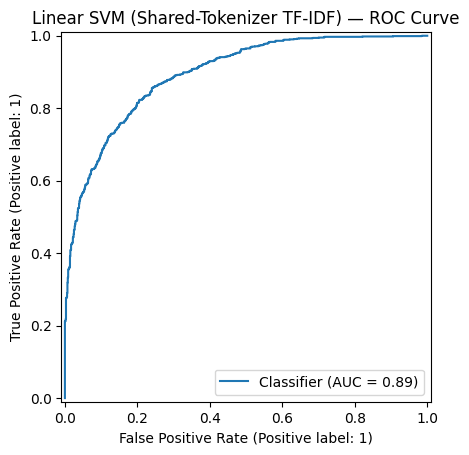

In [9]:
results = []

logreg = LogisticRegression(max_iter=2000)
results.append(evaluate(logreg, X_train_tfidf, y_train, X_test_tfidf, y_test,
                        "Logistic Regression (Shared-Tokenizer TF-IDF)"))

svc = LinearSVC()
results.append(evaluate(svc, X_train_tfidf, y_train, X_test_tfidf, y_test,
                        "Linear SVM (Shared-Tokenizer TF-IDF)"))


#### Loading fine-tuned RoBERTa Model

In [11]:
from transformers import RobertaForSequenceClassification

model_path = r"C:\Users\ajha26\Desktop\IS\models\roberta_finetuned"

roberta_model = RobertaForSequenceClassification.from_pretrained(
    model_path,
    num_labels=2
)

roberta_model.eval()

print("Fine-tuned RoBERTa loaded successfully.")



Fine-tuned RoBERTa loaded successfully.


#### RoBERTa Evaluation on Test Set

In [ ]:
def roberta_predict_proba(texts):
    inputs = tokenizer(texts.tolist(), padding=True, truncation=True,
                       max_length=256, return_tensors="pt")
    with torch.no_grad():
        outputs = roberta_model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    return probs

# Getting predictions
y_proba_roberta = roberta_predict_proba(X_test)
y_pred_roberta = (y_proba_roberta > 0.5).astype(int)


RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


RoBERTa Results:
              precision    recall  f1-score   support

           0      0.938     0.910     0.924      1000
           1      0.913     0.940     0.926      1000

    accuracy                          0.925      2000
   macro avg      0.925     0.925     0.925      2000
weighted avg      0.925     0.925     0.925      2000



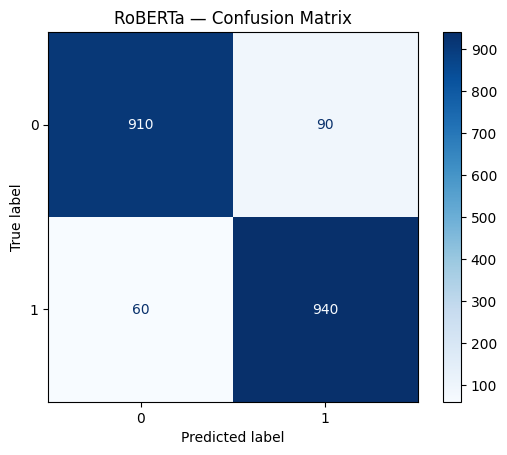

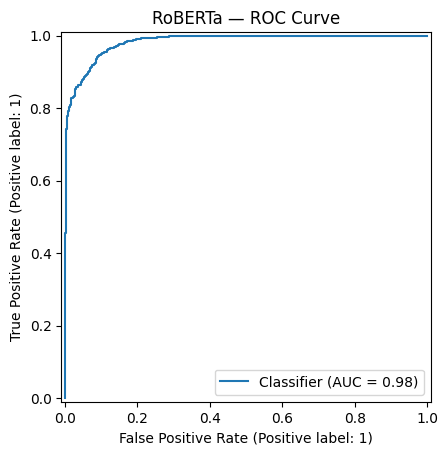

In [13]:
roberta_metrics = {
    "Model": "RoBERTa Fine-Tuned",
    "Accuracy": accuracy_score(y_test, y_pred_roberta),
    "Precision": precision_score(y_test, y_pred_roberta),
    "Recall": recall_score(y_test, y_pred_roberta),
    "F1": f1_score(y_test, y_pred_roberta),
    "ROC-AUC": roc_auc_score(y_test, y_proba_roberta)
}

print("RoBERTa Results:")
print(classification_report(y_test, y_pred_roberta, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_roberta, cmap="Blues")
plt.title("RoBERTa — Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_roberta)
plt.title("RoBERTa — ROC Curve")
plt.show()


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression (Shared-Tokenizer TF-IDF),0.808,0.798,0.824,0.811,0.900
Linear SVM (Shared-Tokenizer TF-IDF),0.804,0.803,0.805,0.804,0.895
RoBERTa Fine-Tuned,0.925,0.913,0.940,0.926,0.983


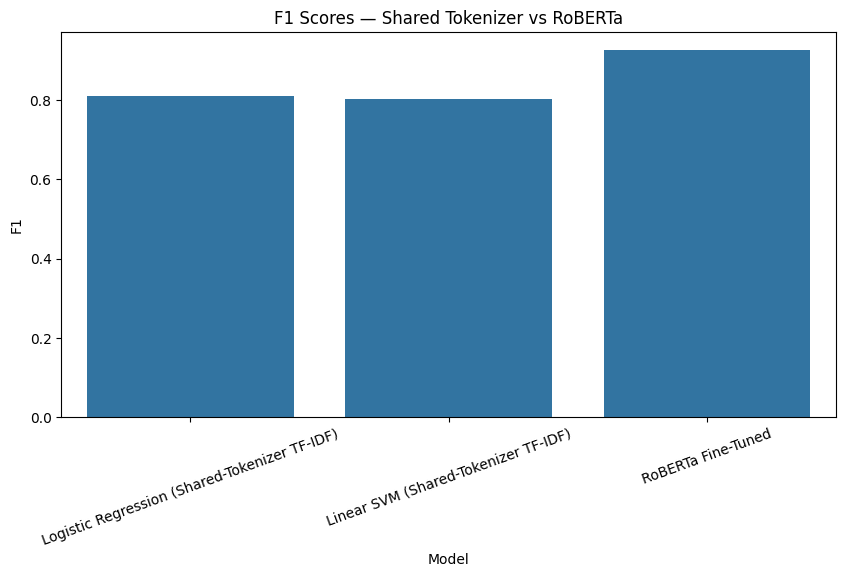

In [14]:
# Combined Performance Summary:

results.append(roberta_metrics)

results_df = pd.DataFrame(results).set_index("Model").round(3)
display(results_df)

plt.figure(figsize=(10,5))
sns.barplot(x=results_df.index, y=results_df["F1"])
plt.title("F1 Scores — Shared Tokenizer vs RoBERTa")
plt.xticks(rotation=20)
plt.show()


#### Interpretability (Linear Models)

Examining the top BPE tokens contributing toward:

AI class

Human class

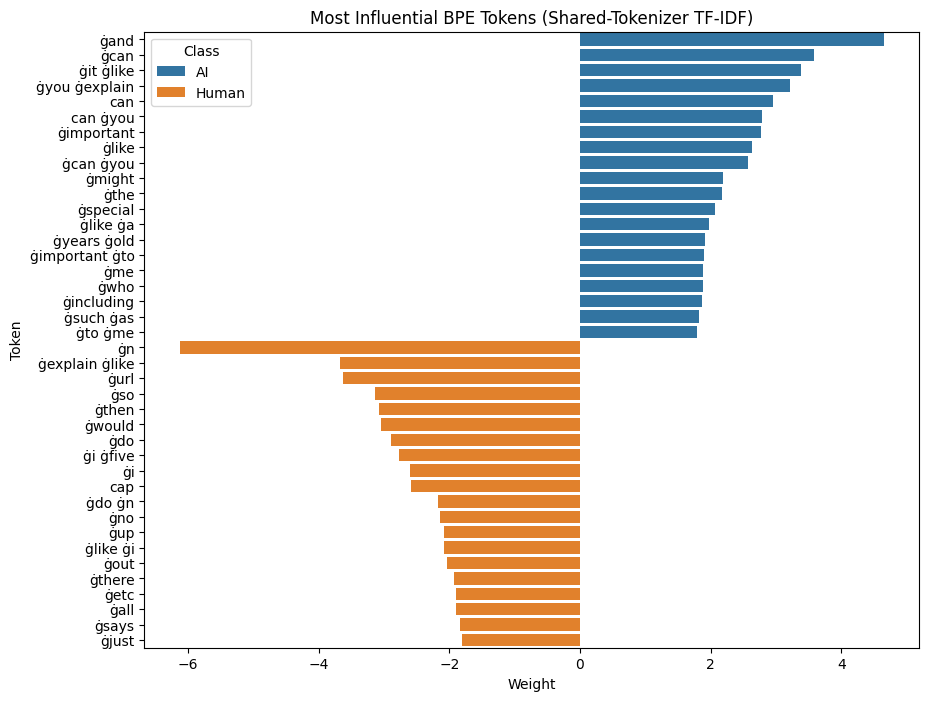

In [15]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = logreg.coef_[0]

top_n = 20
top_ai_idx = np.argsort(coefs)[-top_n:][::-1]
top_human_idx = np.argsort(coefs)[:top_n]

df_imp = pd.DataFrame({
    "Token": list(feature_names[top_ai_idx]) + list(feature_names[top_human_idx]),
    "Weight": list(coefs[top_ai_idx]) + list(coefs[top_human_idx]),
    "Class": ["AI"] * top_n + ["Human"] * top_n
})

plt.figure(figsize=(10,8))
sns.barplot(data=df_imp, x="Weight", y="Token", hue="Class")
plt.title("Most Influential BPE Tokens (Shared-Tokenizer TF-IDF)")
plt.show()


#### UMAP & t-SNE on Shared-Tokenizer TF-IDF

Purpose: Visualize geometric separability of texts under controlled-tokenizer representation.

These plots directly support RQ1 (representation separability).

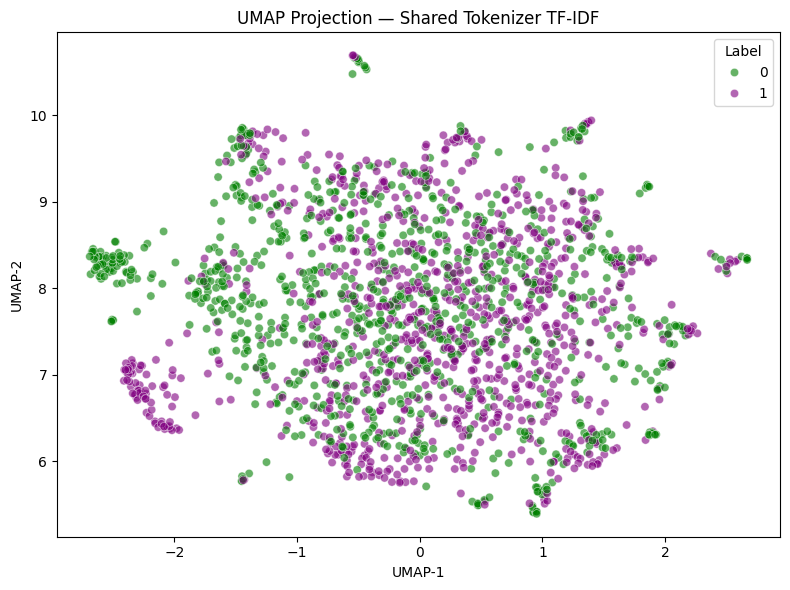

In [16]:
# UMAP(TF-IDF BPE Tokens)

import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    random_state=42
)

tfidf_umap = reducer.fit_transform(X_test_tfidf)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=tfidf_umap[:,0], y=tfidf_umap[:,1],
    hue=y_test,
    palette={0:"green", 1:"purple"},
    alpha=0.6
)
plt.title("UMAP Projection — Shared Tokenizer TF-IDF")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


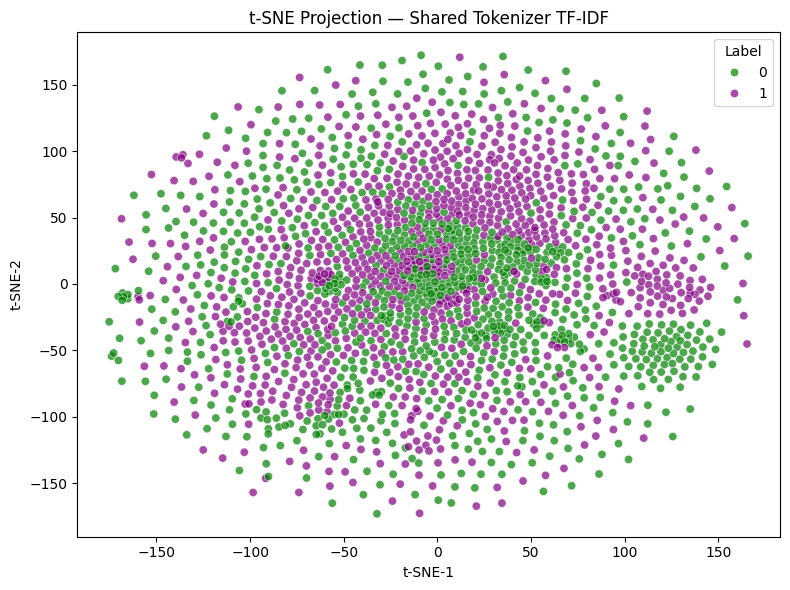

In [ ]:
# t-SNE on TF-IDF (shared tokenizer)

from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate=300,
    random_state=42,
    max_iter=1500
)

# Converting sparse TF-IDF → dense ndarray
dense_tfidf = X_test_tfidf[:2000].toarray()

tfidf_tsne = tsne.fit_transform(dense_tfidf)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=tfidf_tsne[:,0], y=tfidf_tsne[:,1],
    hue=y_test[:2000],
    palette={0:"green", 1:"purple"},
    alpha=0.7
)
plt.title("t-SNE Projection — Shared Tokenizer TF-IDF")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()



#### Cosine-Distance Clustering (Shared Tokenizer)
Measures geometric differences between TF-IDF vectors.

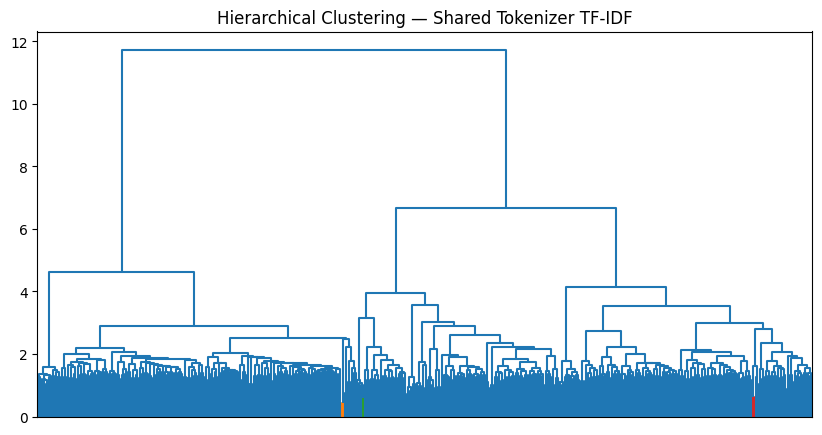

In [22]:
from sklearn.metrics.pairwise import cosine_distances
import scipy.cluster.hierarchy as sch

# compute distance matrix
dist_matrix = cosine_distances(X_test_tfidf[:500])

plt.figure(figsize=(10, 5))
sch.dendrogram(
    sch.linkage(dist_matrix, method='ward'),
    color_threshold=0.7,
    no_labels=True
)
plt.title("Hierarchical Clustering — Shared Tokenizer TF-IDF")
plt.show()


#### Side-by-Side Comparison (UMAP TF-IDF vs CLS Embeddings)

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.scatterplot(
    x=tfidf_umap[:,0], y=tfidf_umap[:,1],
    hue=y_test, alpha=0.6, palette={0:"green", 1:"purple"},
    ax=ax[0]
)
ax[0].set_title("UMAP — Shared Tokenizer TF-IDF")

sns.scatterplot(
    x=emb_umap[:,0], y=emb_umap[:,1],
    hue=y_test, alpha=0.7, palette={0:"green", 1:"purple"},
    ax=ax[1]
)
ax[1].set_title("UMAP — RoBERTa CLS Embeddings")

plt.tight_layout()
plt.show()


#### DBSCAN Clustering (Shared Tokenizer TF-IDF)

Purpose: Identifying whether clusters naturally form in TF-IDF space without labels.

In [23]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# DBSCAN parameters tuned for sparse TF-IDF
dbscan_tfidf = DBSCAN(
    eps=0.35,        # radius; tune if needed
    min_samples=10, 
    metric="cosine",  
    n_jobs=-1
)

tfidf_labels = dbscan_tfidf.fit_predict(X_test_tfidf)

print("DBSCAN cluster labels:", np.unique(tfidf_labels))


DBSCAN cluster labels: [-1]


#### Silhouette Score

Score closer to 1 = better clustering

Note: -1 labels (noise) are automatically removed.

In [24]:
# filter noise points
mask = tfidf_labels != -1
if mask.sum() > 1:
    sil_tfidf = silhouette_score(X_test_tfidf[mask], tfidf_labels[mask], metric="cosine")
else:
    sil_tfidf = np.nan

print(f"Silhouette Score (TF-IDF): {sil_tfidf:.4f}")


Silhouette Score (TF-IDF): nan


#### Cluster Purity Function

In [25]:
from scipy.stats import mode

def cluster_purity(cluster_labels, true_labels):
    clusters = np.unique(cluster_labels)
    purity_scores = []

    for cluster in clusters:
        if cluster == -1:
            continue  # ignore DBSCAN noise
        idx = np.where(cluster_labels == cluster)[0]
        majority_label = mode(true_labels[idx], keepdims=True).mode[0]
        purity = (true_labels[idx] == majority_label).mean()
        purity_scores.append(purity)

    return np.mean(purity_scores) if purity_scores else np.nan


In [26]:
# computing Purity (IT-IDF)

purity_tfidf = cluster_purity(tfidf_labels, y_test.values)
print(f"Cluster Purity (TF-IDF): {purity_tfidf:.4f}")


Cluster Purity (TF-IDF): nan


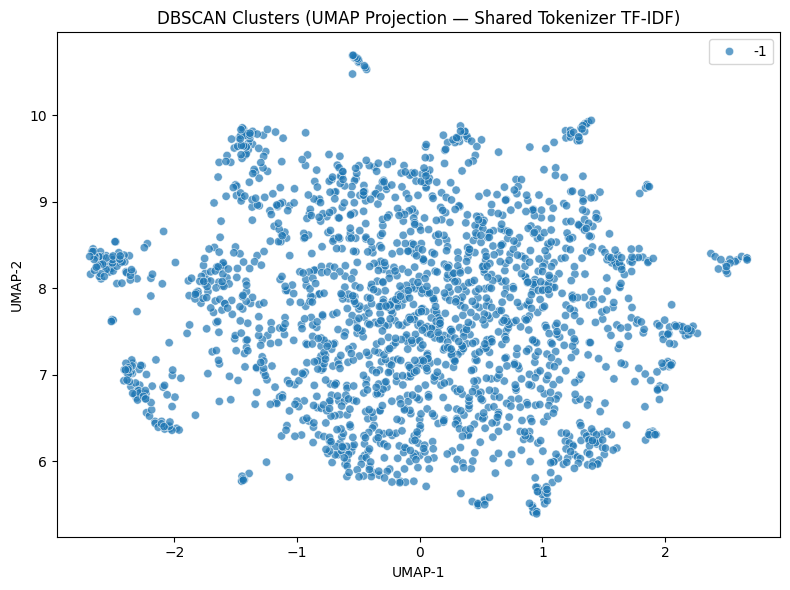

In [27]:
# Visualizing DBSCAN clusters via UMAP

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=tfidf_umap[:,0], y=tfidf_umap[:,1],
    hue=tfidf_labels,
    palette="tab20",
    alpha=0.7
)
plt.title("DBSCAN Clusters (UMAP Projection — Shared Tokenizer TF-IDF)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


Starting UMAP & t-SNE on Shared-Tokenizer TF-IDF...


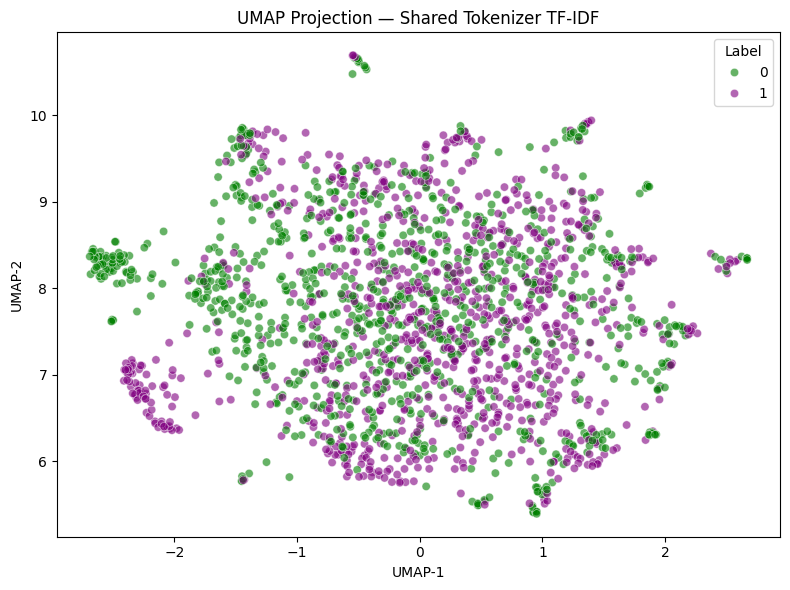

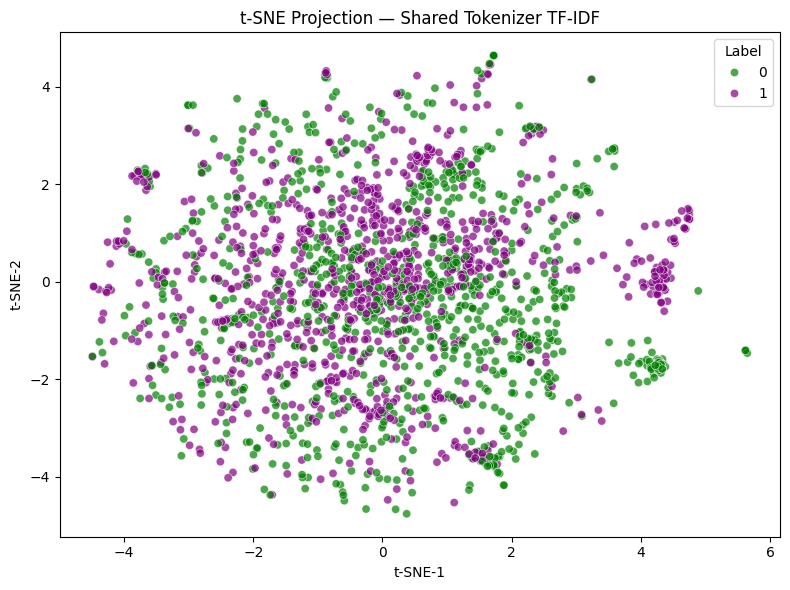

In [ ]:
#### UMAP & t-SNE on Shared-Tokenizer TF-IDF
print("Starting UMAP & t-SNE on Shared-Tokenizer TF-IDF...")

from sklearn.manifold import TSNE
import umap.umap_ as umap

# UMAP 
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    random_state=42
)

tfidf_umap = reducer.fit_transform(X_test_tfidf)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=tfidf_umap[:,0], y=tfidf_umap[:,1],
    hue=y_test,
    palette={0:"green", 1:"purple"},
    alpha=0.6
)
plt.title("UMAP Projection — Shared Tokenizer TF-IDF")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

# ---------- t-SNE ----------
tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    max_iter=1500,
    random_state=42
)

# Convert sparse matrix → dense array
tfidf_small = X_test_tfidf[:2000].toarray()

tfidf_tsne = tsne.fit_transform(tfidf_small)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=tfidf_tsne[:,0], y=tfidf_tsne[:,1],
    hue=y_test[:2000],
    palette={0:"green", 1:"purple"},
    alpha=0.7
)
plt.title("t-SNE Projection — Shared Tokenizer TF-IDF")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()
